In [29]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy

In [30]:
#Define Sudan Bounding box
lon_min = 21.93681
lon_max = 38.4100899559
lat_min = 8.61972971293
lat_max = 22.0 

In [31]:
ds = xr.open_dataset('cru_ts4.07.1901.2022.pre.dat.nc')
ds

<xarray.Dataset>
Dimensions:  (lon: 720, lat: 360, time: 1464)
Coordinates:
  * lon      (lon) float32 -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
  * lat      (lat) float32 -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
  * time     (time) datetime64[ns] 1901-01-16 1901-02-15 ... 2022-12-16
Data variables:
    pre      (time, lat, lon) float32 ...
    stn      (time, lat, lon) float64 ...
Attributes:
    Conventions:  CF-1.4
    title:        CRU TS4.07 Precipitation
    institution:  Data held at British Atmospheric Data Centre, RAL, UK.
    source:       Run ID = 2304141047. Data generated from:pre.2304141039.dtb
    history:      Fri 14 Apr 12:49:03 BST 2023 : User f098 : Program makegrid...
    references:   Information on the data is available at http://badc.nerc.ac...
    comment:      Access to these data is available to any registered CEDA user.
    contact:      support@ceda.ac.uk

In [32]:
#Subset Sudan
Sudan = ds.sel(
    lat=slice(lat_min, lat_max), 
    lon=slice(lon_min, lon_max),
    time=slice('1990-01-01', '2020-12-31'))

In [33]:
Sudan

<xarray.Dataset>
Dimensions:  (lon: 33, lat: 27, time: 372)
Coordinates:
  * lon      (lon) float32 22.25 22.75 23.25 23.75 ... 36.75 37.25 37.75 38.25
  * lat      (lat) float32 8.75 9.25 9.75 10.25 ... 20.25 20.75 21.25 21.75
  * time     (time) datetime64[ns] 1990-01-16 1990-02-15 ... 2020-12-16
Data variables:
    pre      (time, lat, lon) float32 ...
    stn      (time, lat, lon) float64 ...
Attributes:
    Conventions:  CF-1.4
    title:        CRU TS4.07 Precipitation
    institution:  Data held at British Atmospheric Data Centre, RAL, UK.
    source:       Run ID = 2304141047. Data generated from:pre.2304141039.dtb
    history:      Fri 14 Apr 12:49:03 BST 2023 : User f098 : Program makegrid...
    references:   Information on the data is available at http://badc.nerc.ac...
    comment:      Access to these data is available to any registered CEDA user.
    contact:      support@ceda.ac.uk

In [34]:
# Calculating mean precipitation over 1990-2020
mean_precip = Sudan['pre'].mean(dim='time')

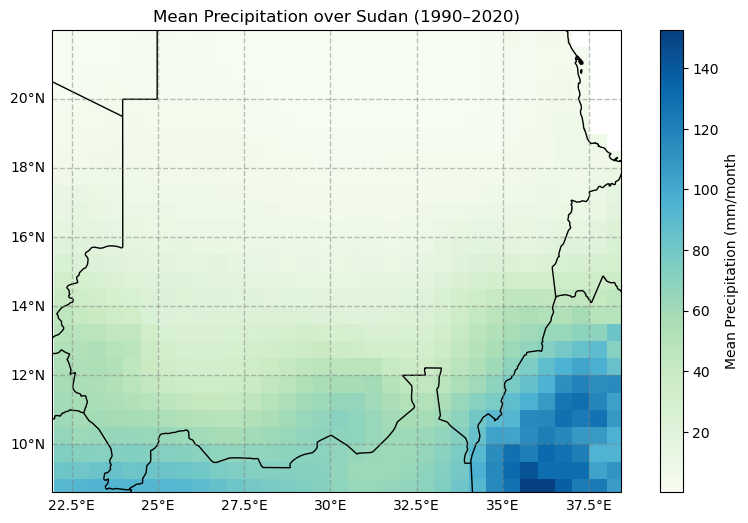

In [35]:
plt.figure(figsize=(10,6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Set Sudan bounding box
ax.set_extent([lon_min, lon_max, lat_min,lat_max], crs=ccrs.PlateCarree())

# Plot mean precipitation
mean_precip.plot(
    cmap='GnBu',
    ax=ax,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'Mean Precipitation (mm/month'})
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)

# Add gridlines with labels
gl = ax.gridlines(draw_labels=True, linewidth=1,
                  color='gray', alpha=0.5, linestyle='--')

gl.top_labels = False
gl.right_labels = False
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
# Axis labels
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.title('Mean Precipitation over Sudan (1990–2020)')
plt.show()

In [36]:
# Calculating Annual mean precipitation over 1990-2020
Annual_precip = Sudan['pre'].groupby ('time.year').sum(dim='time')
Annual_precip

<xarray.DataArray 'pre' (year: 31, lat: 27, lon: 33)>
array([[[ 979.7      ,  994.50006  , 1002.60004  , ..., 1488.3      ,
         1493.3      , 1287.4999   ],
        [ 861.60004  ,  850.10004  ,  862.30005  , ..., 1579.8999   ,
         1174.9      , 1325.       ],
        [ 767.       ,  739.8      ,  698.       , ..., 1261.1002   ,
          976.10004  , 1016.99994  ],
        ...,
        [  11.8      ,   15.500001 ,   17.9      , ...,   17.7      ,
            0.       ,    0.       ],
        [   8.8      ,   11.3      ,   10.8      , ...,   17.2      ,
            0.       ,    0.       ],
        [   6.2999997,    6.7      ,    7.       , ...,    0.       ,
            0.       ,    0.       ]],

       [[1079.5      , 1094.2001   , 1113.6      , ..., 1384.5      ,
         1422.1      , 1205.9      ],
        [ 956.7      ,  934.3      ,  955.50006  , ..., 1509.0001   ,
         1093.2001   , 1129.       ],
        [ 833.60004  ,  803.7999   ,  791.3      , ..., 1430.3      ,
         1017.80005  ,  928.30005  ],
...
        [  12.       ,   15.500001 ,   17.9      , ...,   41.100002 ,
            0.       ,    0.       ],
        [   8.8      ,   11.3      ,   10.8      , ...,   38.9      ,
            0.       ,    0.       ],
        [   6.2999997,    6.7      ,    7.       , ...,    0.       ,
            0.       ,    0.       ]],

       [[1104.7      , 1116.9      , 1133.       , ..., 1670.3      ,
         1689.0001   , 1457.3999   ],
        [ 987.7001   ,  985.30005  , 1021.50006  , ..., 1781.8999   ,
         1420.4      , 1514.7      ],
        [ 897.10004  ,  894.19995  ,  896.80005  , ..., 1659.6002   ,
         1310.3999   , 1299.7      ],
        ...,
        [  12.       ,   15.500001 ,   17.9      , ...,   51.399998 ,
            0.       ,    0.       ],
        [   8.8      ,   11.400001 ,   10.9      , ...,   44.7      ,
            0.       ,    0.       ],
        [   6.3999996,    6.7999997,    7.1      , ...,    0.       ,
            0.       ,    0.       ]]], dtype=float32)
Coordinates:
  * lon      (lon) float32 22.25 22.75 23.25 23.75 ... 36.75 37.25 37.75 38.25
  * lat      (lat) float32 8.75 9.25 9.75 10.25 ... 20.25 20.75 21.25 21.75
  * year     (year) int64 1990 1991 1992 1993 1994 ... 2016 2017 2018 2019 2020
Attributes:
    long_name:                   precipitation
    units:                       mm/month
    correlation_decay_distance:  450.0

In [37]:
annual_mean_precip=Annual_precip.mean(dim='year')

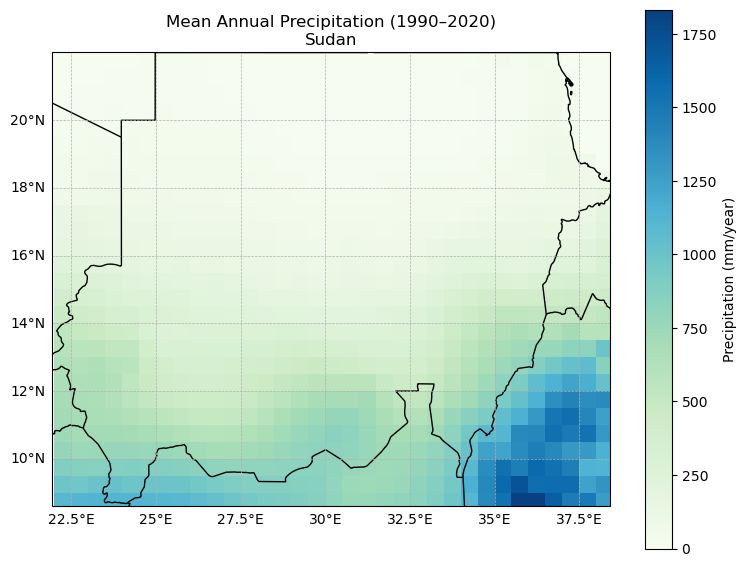

In [38]:
#plot Annual Mean map
plt.figure(figsize=(9,7))

ax = plt.axes(projection=ccrs.PlateCarree())

# Set extent to bounding box
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

annual_mean_precip.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="GnBu",
    cbar_kwargs={'label': 'Precipitation (mm/year)'}
)

ax.add_feature(cfeature.BORDERS, linewidth=1)
ax.add_feature(cfeature.COASTLINE)
gl = ax.gridlines(draw_labels=True, linestyle='--', linewidth=0.5)
gl.top_labels = False
gl.right_labels = False

# Enable Bottom and Left labels
gl.bottom_labels = True
gl.left_labels = True
gl.xformatter = cartopy.mpl.gridliner.LONGITUDE_FORMATTER
gl.yformatter = cartopy.mpl.gridliner.LATITUDE_FORMATTER
plt.title("Mean Annual Precipitation (1990–2020)\nSudan")

plt.show()

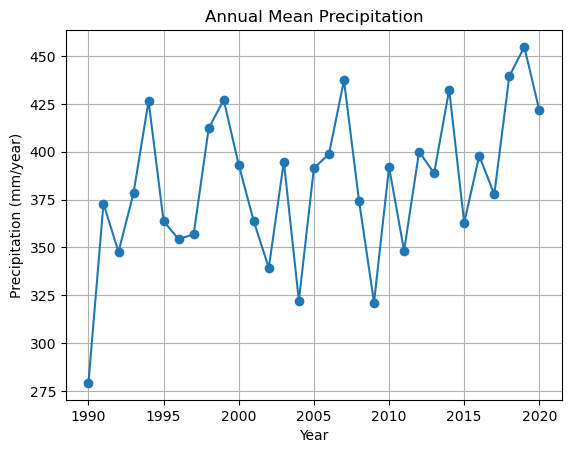

In [39]:
#time series
weights = np.cos(np.deg2rad(Sudan.lat))
annual_mean_series = Annual_precip.weighted(weights).mean(dim=("lat", "lon"))
annual_mean_series.plot(marker='o')
plt.title("Annual Mean Precipitation")
plt.ylabel("Precipitation (mm/year)")
plt.xlabel("Year")
plt.grid(True)
plt.show()

In [40]:
from scipy.stats import linregress

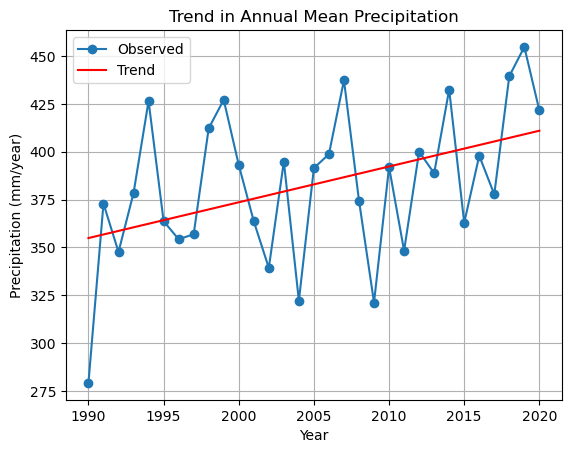

In [41]:
#Trend line
years = annual_mean_series.year.values
values = annual_mean_series.values
slope, intercept, r_value, p_value, std_err = linregress(years, values)
trend_line = intercept + slope * years
plt.plot(years, values, marker='o', label="Observed")
plt.plot(years, trend_line, color='red', label="Trend")
plt.title("Trend in Annual Mean Precipitation")
plt.ylabel("Precipitation (mm/year)")
plt.xlabel("Year")
plt.legend()
plt.grid(True)
plt.show()

In [42]:
#calculating standard deviation
std_dev = annual_mean_series.std().values
print(f"Standard Deviation: {std_dev:.2f} mm/year")

Standard Deviation: 38.82 mm/year


In [44]:
decade1 = Annual_precip.sel(year=slice(1990, 1999)).mean(dim='year')
decade2 = Annual_precip.sel(year=slice(2010, 2020)).mean(dim='year')
difference = decade2 - decade1

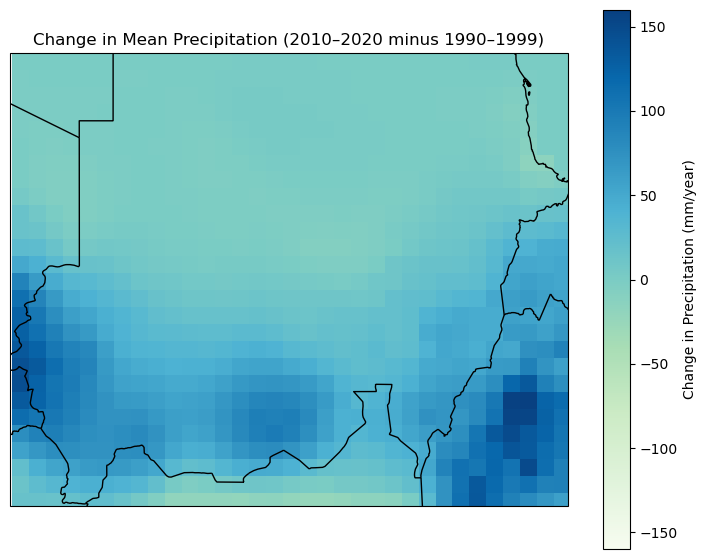

In [53]:
 plt.figure(figsize=(9,7))
ax = plt.axes(projection=ccrs.PlateCarree())
difference.plot(
    ax=ax, transform=ccrs.PlateCarree(), cmap="GnBu", cbar_kwargs={"label": "Change in Precipitation (mm/year)"}
)
ax.coastlines()
ax.add_feature(cfeature.BORDERS)
ax.set_extent([lon_min, lon_max, lat_min,lat_max])
plt.title("Change in Mean Precipitation (2010–2020 minus 1990–1999)")
plt.show()

In [54]:
diff_df = difference.to_dataframe().reset_index()
diff_df = diff_df.dropna()
top_increase = diff_df.nlargest(5, 'pre')
top_decrease = diff_df.nsmallest(5, 'pre')
print("Top 5 Increases:")
print(top_increase[['lat', 'lon', 'pre']])
print("\nTop 5 Decreases:")
print(top_decrease[['lat', 'lon', 'pre']])

Top 5 Increases:
       lat    lon         pre
228  11.75  37.25  159.852783
227  11.75  36.75  158.522705
194  11.25  36.75  155.869873
195  11.25  37.25  154.440796
96    9.75  37.25  149.653687

Top 5 Decreases:
     lat    lon        pre
18  8.75  31.25 -23.359009
17  8.75  30.75 -22.548157
16  8.75  30.25 -21.052673
13  8.75  28.75 -20.402710
19  8.75  31.75 -20.194458


In [56]:
percentile_90 = Annual_precip.quantile(0.9, dim='year')
wet_years = Annual_precip > percentile_90
wet_frequency = wet_years.sum(dim='year')

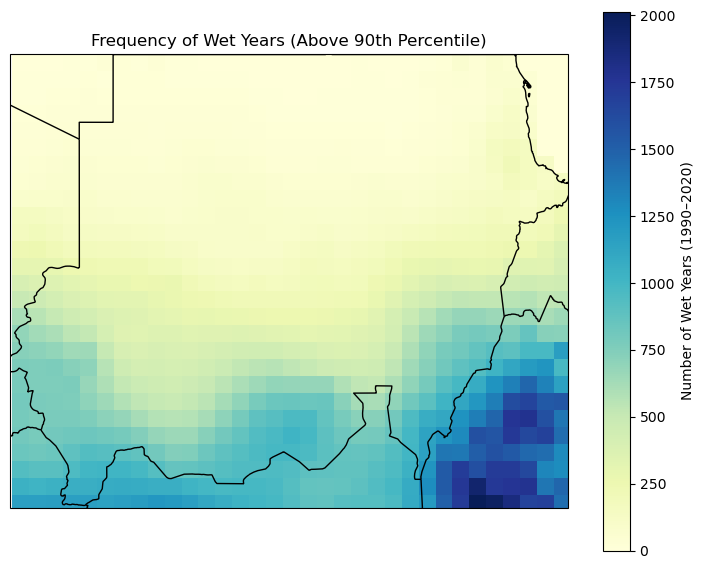

In [58]:
  plt.figure(figsize=(9,7))
ax = plt.axes(projection=ccrs.PlateCarree())

percentile_90.plot(
    ax=ax, transform=ccrs.PlateCarree(), cmap="YlGnBu", cbar_kwargs={"label": "Number of Wet Years (1990–2020)"}
)

ax.coastlines()
ax.add_feature(cfeature.BORDERS)
ax.set_extent([lon_min, lon_max, lat_min,lat_max])
plt.title("Frequency of Wet Years (Above 90th Percentile)")
plt.show()